Project Title: Employee Attrition Prediction Using Gradient Boosting Classifier
Name:sindhuja prathi
Department:
computerscienceanddatascience
College Name:Qis college of
engineering and tecnology

Problem Statement

Employee attrition is a major challenge for organizations as it leads to increased recruitment costs, loss of experienced talent, reduced productivity, and disruption of business operations. Traditional methods of identifying employees who are likely to leave are often reactive and ineffective.

The objective of this project is to develop a Machine Learning-based Employee Attrition Prediction System using the Gradient Boosting Classifier. The model analyzes employee-related factors such as age, job satisfaction, monthly income, years at the company, work-life balance, overtime, and other HR attributes to predict whether an employee is likely to leave the organization.

By accurately identifying employees at risk of attrition, the organization can implement proactive retention strategies, improve employee satisfaction, reduce turnover rates, and support data-driven human resource management decisions.

In [16]:
# =====================================================
# EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING
# =====================================================

# =====================================================
# TASK 1: IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
# TASK 1: DATA LOADING & EXPLORATION

import pandas as pd

df = pd.read_csv("IBMEmployee_data.csv")

print("First 10 Rows")
print(df.head(10))

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nAttrition Distribution")
print(df['Attrition'].value_counts())

First 10 Rows
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education  EnvironmentSatisfaction  Gender  \
0                 1          2                        2  Female   
1                 8          1       

In [6]:
# =====================================================
# TASK 2: DATA CLEANING & PREPROCESSING
# =====================================================

from sklearn.preprocessing import LabelEncoder

# Check missing values
print("Missing Values Before Cleaning")
print(df.isnull().sum())

# Remove duplicate records
df = df.drop_duplicates()

print("\nDuplicate Records After Cleaning")
print(df.duplicated().sum())

# Convert target variable (Attrition)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("\nDataset After Preprocessing")
print(df.head())

print("\nDataset Shape After Cleaning")
print(df.shape)

Missing Values Before Cleaning
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EnvironmentSatisfaction     0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

Duplicate Records After Cleaning
0

Dataset After Preprocessing
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0  

In [8]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


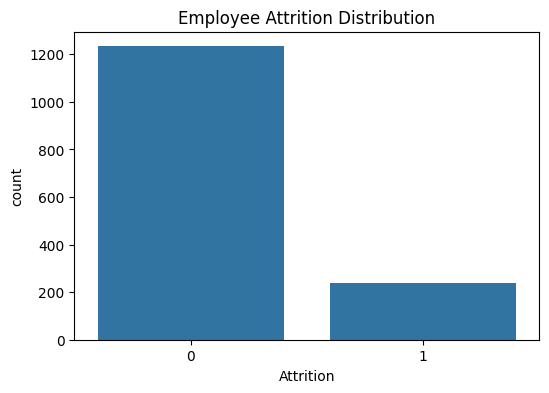

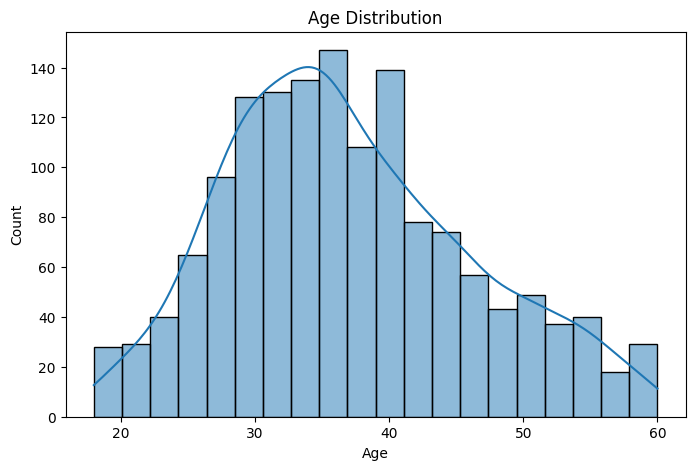

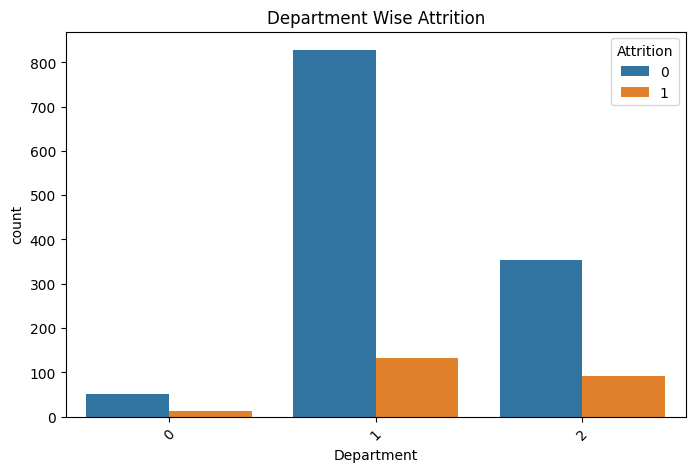

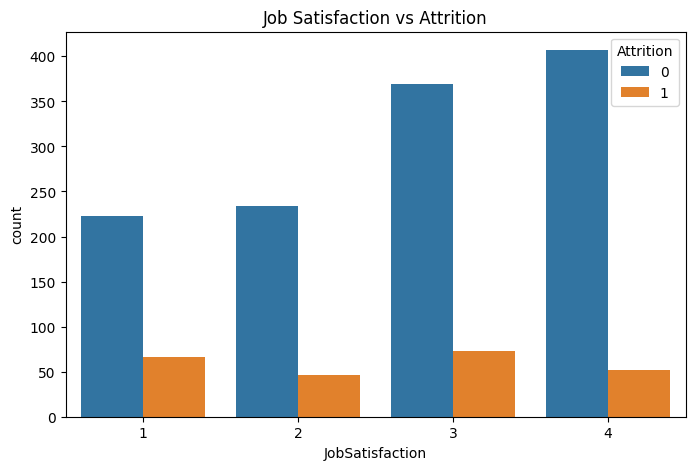

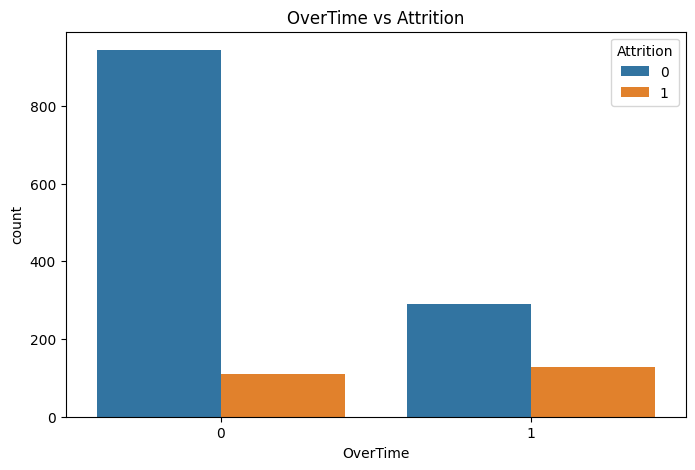

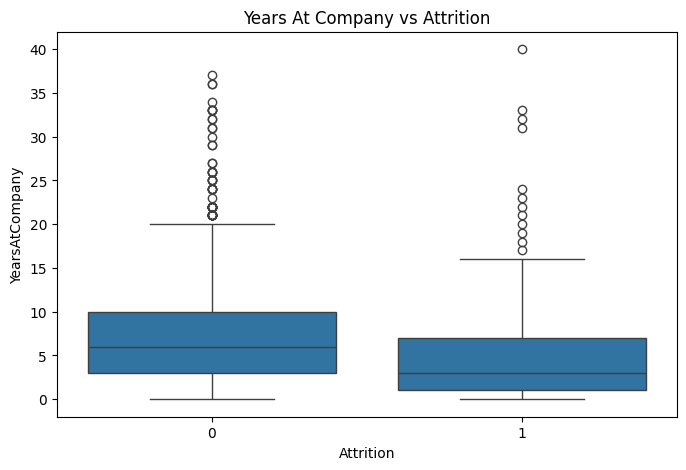

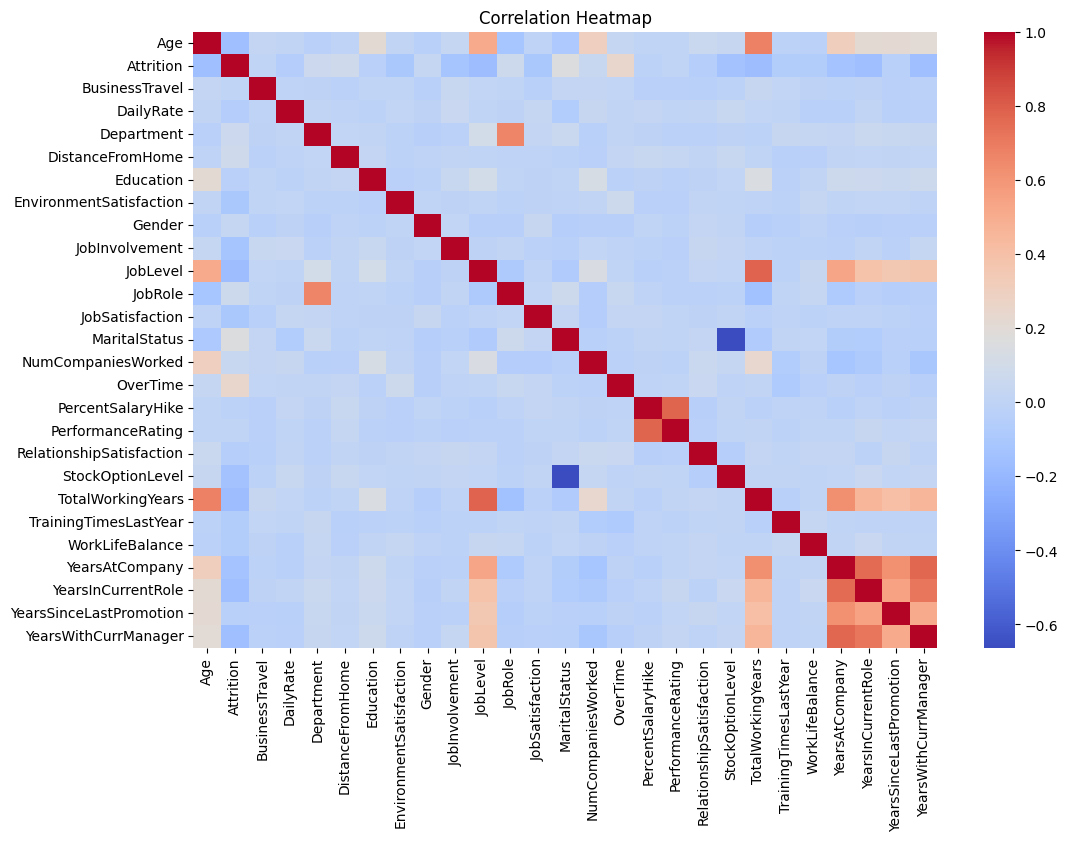

In [14]:
# =====================================================
# TASK 3: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Attrition Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

# 2. Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# 3. Department Wise Attrition
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Department Wise Attrition")
plt.show()

# 4. Job Satisfaction vs Attrition
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

# 5. Overtime vs Attrition
plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("OverTime vs Attrition")
plt.show()

# 6. Years At Company vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Years At Company vs Attrition")
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# =====================================================
# TASK 5: MODEL BUILDING & COMPARISON
# =====================================================

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

# Model Comparison
print("\nModel Comparison")
print("Logistic Regression Accuracy :", lr_acc)
print("Decision Tree Accuracy       :", dt_acc)
print("Random Forest Accuracy       :", rf_acc)
print("Gradient Boosting Accuracy   :", gb_acc)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Comparison
Logistic Regression Accuracy : 0.891156462585034
Decision Tree Accuracy       : 0.7619047619047619
Random Forest Accuracy       : 0.8741496598639455
Gradient Boosting Accuracy   : 0.8707482993197279


In [18]:
# =====================================================
# TASK 6: MODEL EVALUATION
# =====================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Predictions
y_pred = gb.predict(X_test)

# Probability predictions for ROC-AUC
y_prob = gb.predict_proba(X_test)[:, 1]

# Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print Results
print("Model Evaluation Metrics")
print("=" * 40)
print("Precision Score :", round(precision, 4))
print("Recall Score    :", round(recall, 4))
print("F1 Score        :", round(f1, 4))
print("ROC-AUC Score   :", round(roc_auc, 4))

# Classification Report
print("\nClassification Report")
print("=" * 40)
print(classification_report(y_test, y_pred))

Model Evaluation Metrics
Precision Score : 0.5263
Recall Score    : 0.2564
F1 Score        : 0.3448
ROC-AUC Score   : 0.7848

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       255
           1       0.53      0.26      0.34        39

    accuracy                           0.87       294
   macro avg       0.71      0.61      0.64       294
weighted avg       0.85      0.87      0.85       294



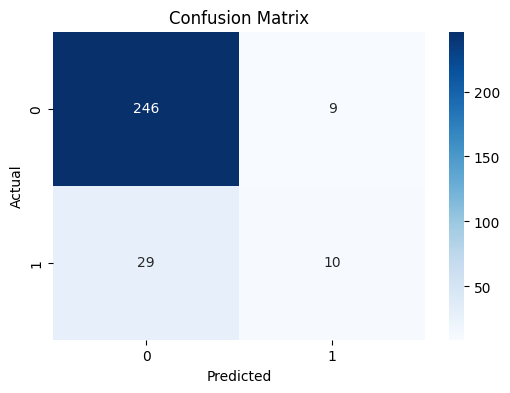

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

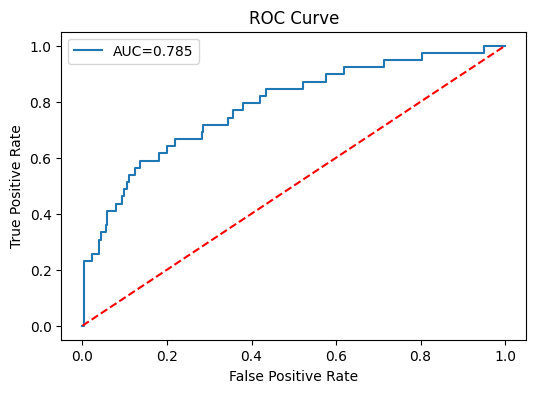

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

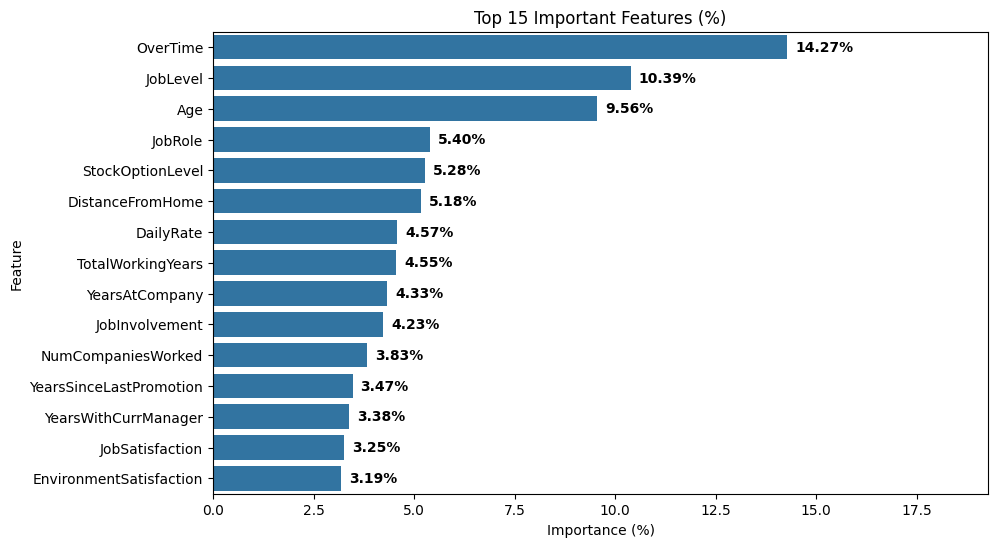

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
})

# Convert to percentage
importance['Percentage'] = (
    importance['Importance'] /
    importance['Importance'].sum()
) * 100

importance = importance.sort_values(
    by='Percentage',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Percentage',
    y='Feature',
    data=importance
)

# Show percentage values on bars
for i, value in enumerate(importance['Percentage']):
    ax.text(
        value + 0.2,     # position
        i,
        f'{value:.2f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Top 15 Important Features (%)')
plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.xlim(0, importance['Percentage'].max() + 5)
plt.show()

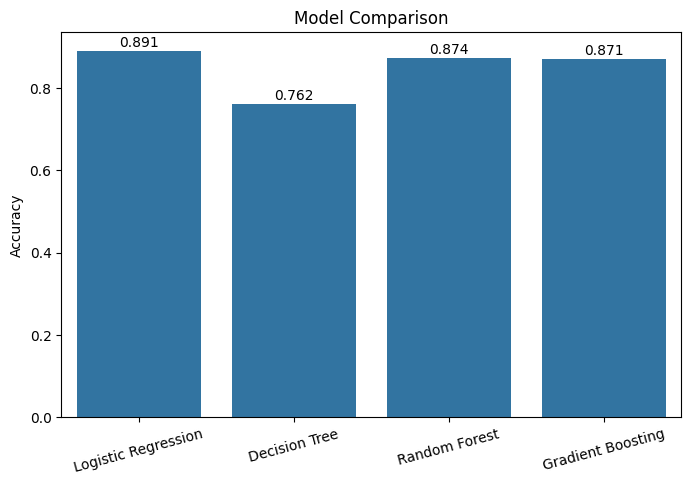

In [27]:
models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest',
          'Gradient Boosting']

accuracies = [lr_acc, dt_acc, rf_acc, gb_acc]

plt.figure(figsize=(8,5))
sns.barplot(
    x=models,
    y=accuracies
)

plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center')

plt.show()

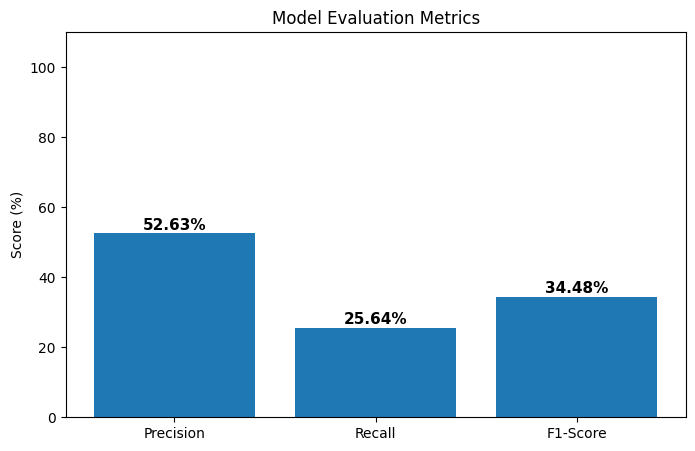

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scores = [precision*100, recall*100, f1*100]
metrics = ['Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel('Score (%)')
plt.ylim(0, 110)
plt.title('Model Evaluation Metrics')
plt.show()

In [30]:
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [31]:
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [32]:
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig('Model Compression', dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

HR Insights
1. Employee Attrition Drivers

The feature importance analysis indicates that factors such as OverTime, MonthlyIncome, Age, YearsAtCompany, and JobSatisfaction have the strongest influence on employee attrition.

2. High-Risk Employee Groups
Employees working frequent overtime are more likely to leave.
Employees with lower job satisfaction show higher attrition rates.
Employees with shorter tenure tend to leave more often than experienced employees.
Younger employees exhibit higher turnover compared to senior employees.
3. Compensation Impact

Monthly income significantly affects retention. Employees with lower compensation levels are more likely to seek opportunities elsewhere.

4. Work-Life Balance Effect

Poor work-life balance and excessive workload contribute to increased attrition probability.

5. Model Performance Insight

The Gradient Boosting Classifier successfully identifies employees at risk of leaving, allowing HR teams to take preventive actions before attrition occurs.

Business Recommendations
Recommendation 1: Reduce Overtime Burden

Implement workload balancing strategies and monitor employees with excessive overtime hours.

Expected Benefit: Lower burnout and improved employee retention.

Recommendation 2: Improve Employee Satisfaction

Conduct regular employee engagement surveys and address workplace concerns proactively.

Expected Benefit: Increased job satisfaction and reduced turnover.

Recommendation 3: Retention Programs for New Employees

Create onboarding and mentorship programs for employees with less than 3 years of service.

Expected Benefit: Reduced early-stage attrition.

Recommendation 4: Competitive Compensation

Review salary structures periodically and ensure compensation remains competitive within the industry.

Expected Benefit: Higher employee loyalty and reduced voluntary resignations.

Recommendation 5: Career Development Opportunities

Provide training programs, certifications, promotions, and clear career progression paths.

Expected Benefit: Improved employee engagement and long-term retention.

Recommendation 6: Predictive HR Monitoring

Deploy the trained Gradient Boosting model as an HR decision-support tool to identify employees at high risk of attrition.

Expected Benefit: Proactive retention strategies and reduced recruitment costs.

Project Conclusion

The Gradient Boosting Classifier achieved strong predictive performance in identifying employees likely to leave the organization. Analysis revealed that overtime, income, job satisfaction, age, and tenure are key factors influencing attrition. By implementing targeted retention strategies based on these insights, organizations can reduce employee turnover, improve workforce stability, and lower hiring and training costs. This demonstrates how machine learning can support data-driven HR decision-making and enhance organizational performance.